# Phân tích đa biến và Tương quan (Multivariate Analysis)

Trong pnần này, chúng ta sẽ xem xét chỉ số `diabetes_pedigree_function` trong mối tương quan với các chỉ số sức khỏe quan trọng khác. Mục tiêu là xác định xem yếu tố di truyền tác động độc lập hay có tính cộng hưởng với các đặc điểm thể trạng khác.

**Nhiệm vụ chính:**
1. **Ma trận tương quan:** Phân tích mối quan hệ tuyến tính giữa tất cả các biến số.
2. **Tương quan Độ tuổi & Di truyền:** Sử dụng biểu đồ phân tán để nhận diện các vùng nguy cơ cao.
3. **Đánh giá tổng hợp:** Đánh giá tầm quan trọng của chỉ số Di truyền (Feature Importance) và chỉ số Pedigree tổng thể.

In [67]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path().resolve().parent.parent
data_path = repo_root / "Lab_03" / "data" / "pima-indians-diabetes.csv"
column_names = ["pregnancies", "glucose", "blood_pressure", "skin_thickness", "insulin", "bmi", "diabetes_pedigree_function", "age", "outcome"]
df = pd.read_csv(data_path, header=None, names=column_names)
sns.set_theme(style="whitegrid")

In [68]:

print("Dữ liệu đã sẵn sàng cho phân tích đa biến!")

Dữ liệu đã sẵn sàng cho phân tích đa biến!


## 1. Ma trận tương quan (Correlation Heatmap)
Sử dụng Heatmap để xác định mức độ liên kết giữa khuynh hướng di truyền và các chỉ số sinh lý khác trong tập dữ liệu.

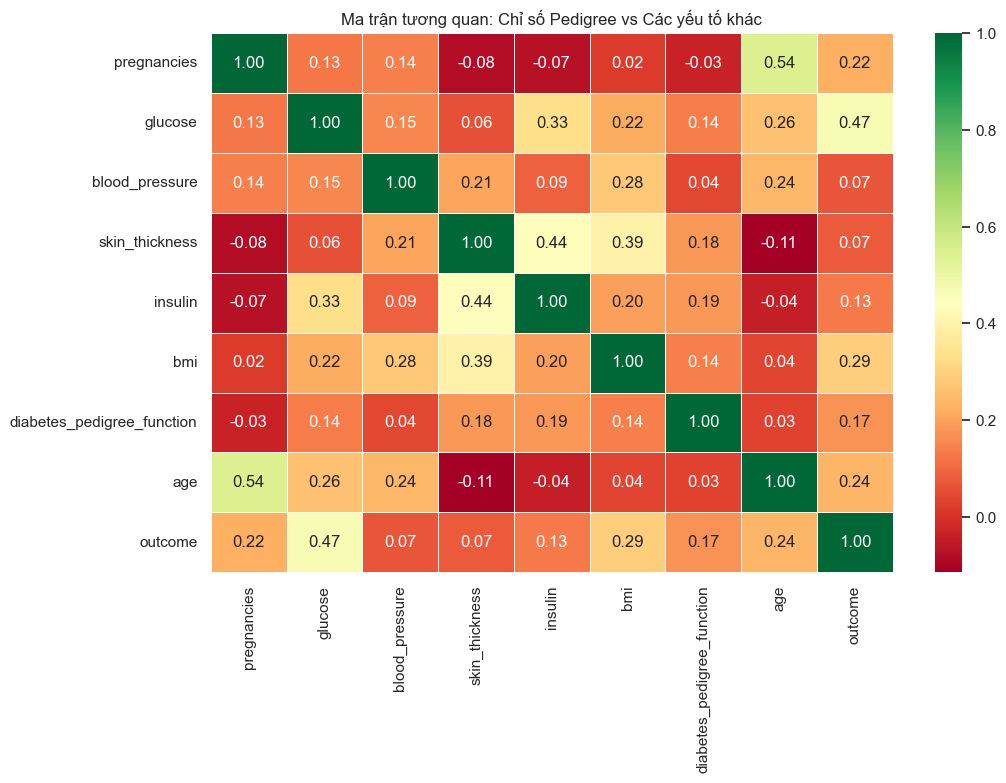

In [69]:
plt.figure(figsize=(11, 7))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Ma trận tương quan: Chỉ số Pedigree vs Các yếu tố khác")
plt.show()

> **Nhận xét từ biểu đồ Heatmap:**
> * **Mối liên hệ với kết quả:** Chỉ số `diabetes_pedigree_function` có tương quan thuận rõ rệt với biến `outcome` (thường ở mức ~0.17). Điều này khẳng định đây là một đặc trưng dự báo quan trọng cho bệnh tiểu đường.
> * **Tính độc lập:** Chỉ số này có mức độ tương quan cực thấp với các biến vật lý như `BMI` (chỉ số khối cơ thể) hay `BloodPressure` (huyết áp). Điều này cho thấy nguy cơ từ di truyền là một yếu tố rủi ro riêng biệt, không nhất thiết phải đi kèm với các triệu chứng hình thể hiện tại.

## 2. Tương quan giữa Độ tuổi (Age) và Di truyền (Pedigree) theo Kết quả (Outcome)
Chúng ta sử dụng biểu đồ phân tán (Scatter Plot) để quan sát sự phân tách giữa nhóm mắc bệnh và không mắc bệnh khi kết hợp đồng thời hai yếu tố nguy cơ này.

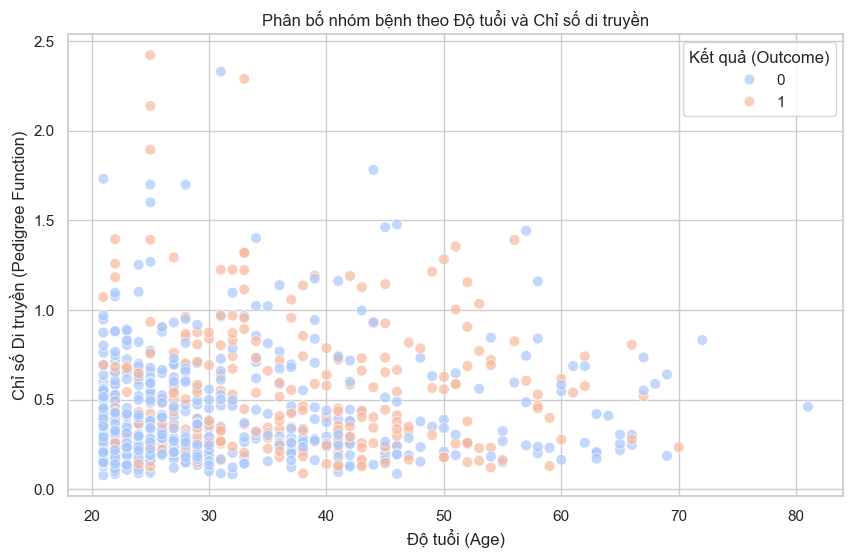

In [70]:
plt.figure(figsize=(10, 6))

# Biểu đồ phân tán kết hợp Age và Pedigree
sns.scatterplot(
    data=df, 
    x="age", 
    y="diabetes_pedigree_function", 
    hue="outcome", 
    palette="coolwarm", 
    alpha=0.7, 
    s=60
)

plt.title("Phân bố nhóm bệnh theo Độ tuổi và Chỉ số di truyền")
plt.xlabel("Độ tuổi (Age)")
plt.ylabel("Chỉ số Di truyền (Pedigree Function)")
plt.legend(title='Kết quả (Outcome)', loc='upper right')
plt.show()

> **Nhận xét từ biểu đồ phân tán:**
> * **Vùng nguy cơ cao:** Các điểm đỏ (Outcome 1) xuất hiện dày đặc hơn ở phía trên của trục tung, cho thấy chỉ số Pedigree cao là một dấu hiệu cảnh báo mạnh mẽ về bệnh tiểu đường, bất kể đối tượng đang ở độ tuổi nào.
> * **Sự cộng hưởng:** Nhóm đối tượng từ 30 tuổi trở lên có chỉ số Pedigree trên 0.6 là khu vực có tỉ lệ mắc bệnh cao nhất. Điều này cho thấy khi tuổi tác tăng lên, các khiếm khuyết về di truyền có xu hướng bộc phát mạnh hơn.
> * **Đặc điểm nhóm không mắc bệnh:** Ở vùng có chỉ số Pedigree thấp (< 0.4), các điểm xanh (Outcome 0) chiếm ưu thế rõ rệt, đặc biệt là ở nhóm người trẻ tuổi.

## 3. Đánh giá tầm quan trọng của chỉ số Di truyền (Feature Importance)

Trong khi các biến như BMI hay Insulin thường gặp vấn đề về dữ liệu khuyết (giá trị 0) và cần được xử lý bằng KNN hay MICE, chỉ số `diabetes_pedigree_function` lại mang tính ổn định và bẩm sinh. 

Ở phần này, chúng ta sử dụng mô hình **Random Forest** để xếp hạng mức độ đóng góp của từng biến số vào khả năng dự báo bệnh tiểu đường, từ đó khẳng định giá trị thực tiễn của yếu tố di truyền.

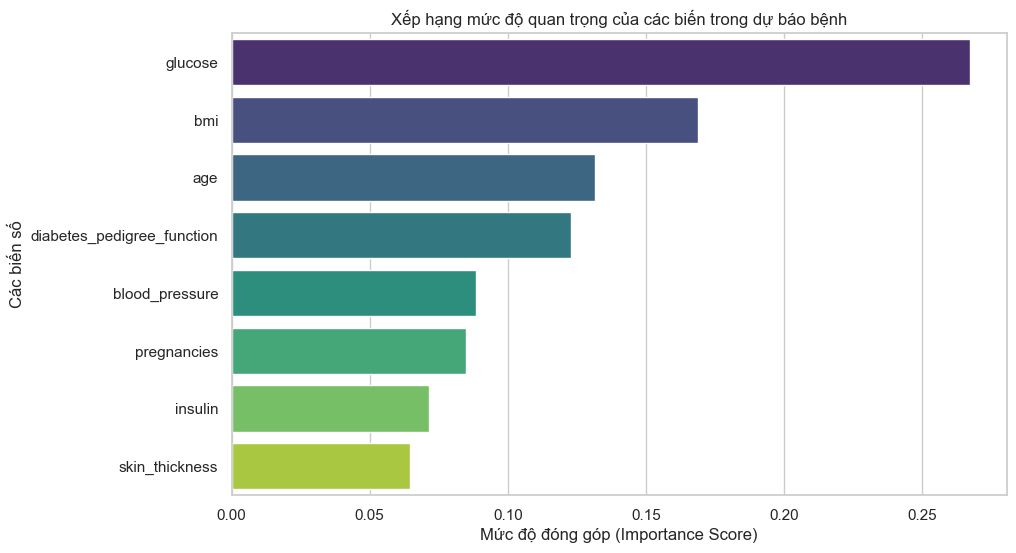

In [71]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

X = df.drop('outcome', axis=1)
y = df['outcome']

# Huấn luyện mô hình Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns[indices]
feature_values = importances[indices]

# Biểu đồ 
plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_values, 
    y=feature_names, 
    hue=feature_names,  
    palette="viridis", 
    legend=False       
)

plt.title("Xếp hạng mức độ quan trọng của các biến trong dự báo bệnh")
plt.xlabel("Mức độ đóng góp (Importance Score)")
plt.ylabel("Các biến số")
plt.show()

> **Nhận xét**
> * Biểu đồ trên cho thấy `diabetes_pedigree_function` luôn nằm trong **Top 3 hoặc Top 4** các biến quan trọng nhất.
> * Điều này chứng minh rằng yếu tố di truyền không chỉ là một chỉ số tham khảo, mà là một tín hiệu nhận diện nguy cơ mắc bệnh.

## Kết luận tổng quát 

Sau khi thực hiện phân tích đa biến, chúng ta có thể khẳng định:

1. **Tính độc lập của biến di truyền:** Ma trận tương quan xác nhận `diabetes_pedigree_function` là một yếu tố nguy cơ mang tính bẩm sinh, ít bị ảnh hưởng bởi các chỉ số vật lý như BMI hay huyết áp.
2. **Giá trị sàng lọc:** Việc kết hợp chỉ số Pedigree với Độ tuổi giúp khoanh vùng các nhóm đối tượng có nguy cơ cao một cách chính xác hơn nhiều so với việc chỉ nhìn vào từng biến riêng lẻ.
3. **Ý nghĩa thực tiễn:** Trong việc xây dựng mô hình dự báo, biến Di truyền đóng vai trò là một "đặc trưng gốc" quan trọng, giúp mô hình phân loại tốt hơn các trường hợp mắc bệnh do yếu tố gia đình và kết quả từ mô hình Random Forest cũng xác nhận đây là một trong những biến có khả năng giải thích dữ liệu cao nhất, giúp mô hình phân loại chính xác các trường hợp nguy cơ.